<a href="https://colab.research.google.com/github/keermani006/MACHINE-LEARNING/blob/main/LAB-3/ML_LAB_3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Tree Classification for Weather-Based Activity Prediction

## Aim

The objective of this experiment is to develop a Decision Tree Classification model that predicts whether a person should 'Go Out' or 'Stay In' based on various weather conditions.

## Problem Description

Weather conditions significantly influence a person's decision to engage in outdoor or indoor activities. For instance, sunny weather might encourage going out for a picnic, while rainy weather might lead to staying indoors to watch a movie. This task is framed as a binary classification problem where the model will predict one of two classes:

- **Go Out**
- **Stay In**

The input features will be different weather parameters, and the output will be the predicted decision.

## Dataset Description

Since no specific dataset was provided, a small illustrative dataset has been created for this experiment. This dataset contains realistic combinations of weather conditions and a binary 'Go Out' / 'Stay In' decision. The features and their descriptions are as follows:

| Variable    | Type        | Description                                  |
| :---------- | :---------- | :------------------------------------------- |
| Outlook     | Categorical | General weather condition (e.g., Sunny, Overcast, Rainy) |
| Temperature | Numerical   | Temperature in Celsius                     |
| Humidity    | Numerical   | Humidity level as a percentage               |
| Windy       | Categorical | Whether it is windy (True or False)          |
| Decision    | Binary      | The target variable: Go Out or Stay In       |

In [1]:
# ============================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
# ============================================
# 2. LOAD / CREATE DATASET
# ============================================

data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rainy', 'Rainy', 'Sunny', 'Rainy', 'Sunny', 'Overcast', 'Rainy', 'Sunny', 'Overcast', 'Overcast', 'Rainy', 'Sunny'],
    'Temperature': [29, 28, 22, 18, 15, 30, 16, 25, 20, 19, 27, 23, 24, 17, 26],
    'Humidity': [65, 70, 90, 95, 92, 60, 98, 75, 85, 88, 68, 80, 78, 93, 72],
    'Windy': [False, True, False, True, False, False, True, False, False, False, True, True, False, False, False],
    'Decision': ['Go Out', 'Go Out', 'Go Out', 'Stay In', 'Stay In', 'Go Out', 'Stay In', 'Go Out', 'Go Out', 'Stay In', 'Stay In', 'Go Out', 'Go Out', 'Stay In', 'Go Out']
}
df = pd.DataFrame(data)

In [3]:
# ============================================
# 3. DISPLAY DATASET
# ============================================

display(df.head())

,Outlook,Temperature,Humidity,Windy,Decision
0,Sunny,29,65,False,Go Out
1,Sunny,28,70,True,Go Out
2,Overcast,22,90,False,Go Out
3,Rainy,18,95,True,Stay In
4,Rainy,15,92,False,Stay In


In [4]:
# ============================================
# 4. DATASET DIMENSIONS
# ============================================

print(f"Dataset dimensions (rows, columns): {df.shape}")

Dataset dimensions (rows, columns): (15, 5)


In [5]:
# ============================================
# 5. DATASET INFORMATION
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Outlook      15 non-null     object
 1   Temperature  15 non-null     int64 
 2   Humidity     15 non-null     int64 
 3   Windy        15 non-null     bool  
 4   Decision     15 non-null     object
dtypes: bool(1), int64(2), object(2)
memory usage: 627.0+ bytes


In [6]:
# ============================================
# 6. STATISTICAL SUMMARY
# ============================================

display(df.describe())

,Temperature,Humidity
count,15.00000,15.000000
mean,22.60000,80.600000
std,4.91063,11.974974
min,15.00000,60.000000
25%,18.50000,71.000000
50%,23.00000,80.000000
75%,26.50000,91.000000
max,30.00000,98.000000


In [7]:
# ============================================
# 7. CHECK MISSING VALUES
# ============================================

print("Missing values per column:")
display(df.isnull().sum())

Missing values per column:


,0
Outlook,0
Temperature,0
Humidity,0
Windy,0
Decision,0


Distribution of the target variable 'Decision':


,count
Decision,
Go Out,9
Stay In,6


/tmp/ipykernel_2405/3172757950.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Decision', data=df, palette='viridis')


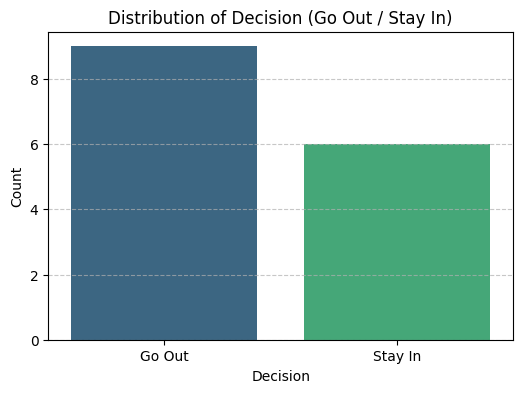

In [8]:
# ============================================
# 8. CHECK TARGET VALUES
# ============================================

print("Distribution of the target variable 'Decision':")
display(df['Decision'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='Decision', data=df, palette='viridis')
plt.title('Distribution of Decision (Go Out / Stay In)')
plt.xlabel('Decision')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Exploratory Data Analysis

This section performs exploratory data analysis to understand the distributions of features and their relationships with the target variable, 'Decision'.

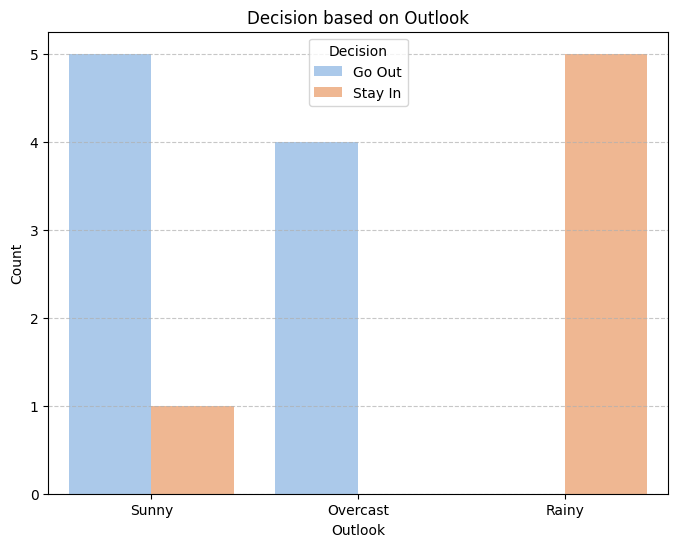

In [9]:
# ============================================
# 9. WEATHER VS DECISION
# ============================================

plt.figure(figsize=(8, 6))
sns.countplot(x='Outlook', hue='Decision', data=df, palette='pastel')
plt.title('Decision based on Outlook')
plt.xlabel('Outlook')
plt.ylabel('Count')
plt.legend(title='Decision')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_2405/909217910.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Decision', y='Temperature', data=df, palette='coolwarm')


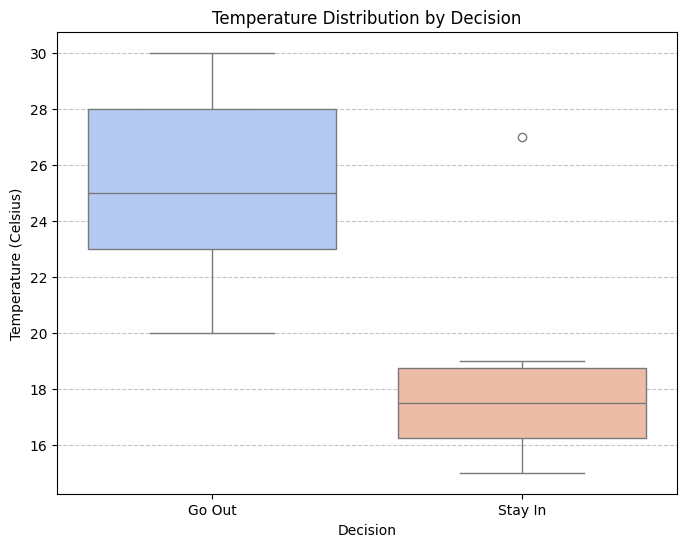

In [10]:
# ============================================
# 10. TEMPERATURE VS DECISION
# ============================================

plt.figure(figsize=(8, 6))
sns.boxplot(x='Decision', y='Temperature', data=df, palette='coolwarm')
plt.title('Temperature Distribution by Decision')
plt.xlabel('Decision')
plt.ylabel('Temperature (Celsius)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_2405/3311738836.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Decision', y='Humidity', data=df, palette='magma')


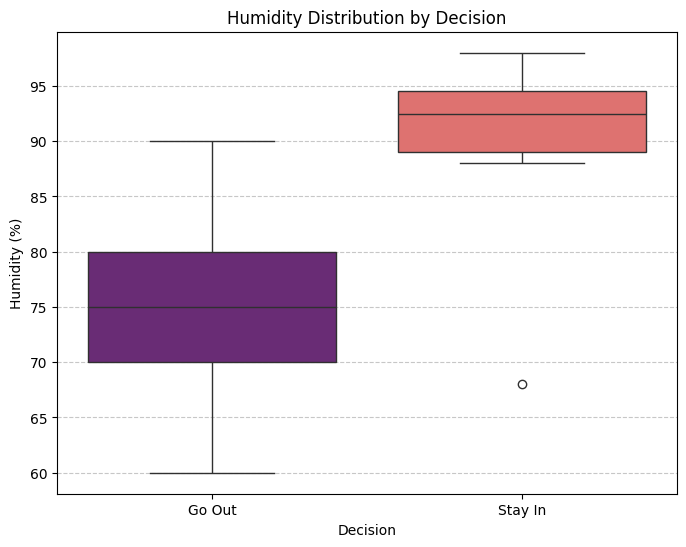

In [11]:
# ============================================
# 11. HUMIDITY VS DECISION
# ============================================

plt.figure(figsize=(8, 6))
sns.boxplot(x='Decision', y='Humidity', data=df, palette='magma')
plt.title('Humidity Distribution by Decision')
plt.xlabel('Decision')
plt.ylabel('Humidity (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [12]:
# ============================================
# 12. ENCODE CATEGORICAL VARIABLES
# ============================================

# Convert categorical features into numerical using one-hot encoding
df_encoded = pd.get_dummies(df, columns=['Outlook', 'Windy'], drop_first=False)

# Map the target variable 'Decision' to numerical values
# 'Stay In' = 0, 'Go Out' = 1
decision_mapping = {'Stay In': 0, 'Go Out': 1}
df_encoded['Decision_encoded'] = df_encoded['Decision'].map(decision_mapping)

print("Dataset after encoding categorical variables:")
display(df_encoded.head())

Dataset after encoding categorical variables:


,Temperature,Humidity,Decision,Outlook_Overcast,Outlook_Rainy,Outlook_Sunny,Windy_False,Windy_True,Decision_encoded
0,29,65,Go Out,False,False,True,True,False,1
1,28,70,Go Out,False,False,True,False,True,1
2,22,90,Go Out,True,False,False,True,False,1
3,18,95,Stay In,False,True,False,False,True,0
4,15,92,Stay In,False,True,False,True,False,0


In [13]:
# ============================================
# 13. DEFINE FEATURES AND TARGET
# ============================================

X = df_encoded.drop(['Decision', 'Decision_encoded'], axis=1)
y = df_encoded['Decision_encoded']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("Features columns:", X.columns.tolist())

Features (X) shape: (15, 7)
Target (y) shape: (15,)
Features columns: ['Temperature', 'Humidity', 'Outlook_Overcast', 'Outlook_Rainy', 'Outlook_Sunny', 'Windy_False', 'Windy_True']


In [14]:
# ============================================
# 14. TRAIN-TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (10, 7)
X_test shape: (5, 7)
y_train shape: (10,)
y_test shape: (5,)


In [15]:
# ============================================
# 15. CREATE DECISION TREE MODEL
# ============================================

# Initialize the Decision Tree Classifier with 'gini' criterion and a reasonable max_depth
model = DecisionTreeClassifier(criterion='gini', random_state=42, max_depth=3)

print(f"Decision Tree Model created with criterion: {model.criterion} and max_depth: {model.max_depth}")

Decision Tree Model created with criterion: gini and max_depth: 3


In [16]:
# ============================================
# 16. TRAIN THE MODEL
# ============================================

model.fit(X_train, y_train)
print("Decision Tree Model trained successfully!")

Decision Tree Model trained successfully!


In [17]:
# ============================================
# 17. MAKE PREDICTIONS
# ============================================

y_pred = model.predict(X_test)
print("Predictions made on the test set.")

Predictions made on the test set.


In [18]:
# ============================================
# 18. COMPARE ACTUAL AND PREDICTED VALUES
# ============================================

# Create a DataFrame to compare actual and predicted values
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
results_df['Actual_Decision'] = results_df['Actual'].map({0: 'Stay In', 1: 'Go Out'})
results_df['Predicted_Decision'] = results_df['Predicted'].map({0: 'Stay In', 1: 'Go Out'})
display(results_df[['Actual_Decision', 'Predicted_Decision']].head())

,Actual_Decision,Predicted_Decision
9,Stay In,Stay In
11,Go Out,Go Out
0,Go Out,Stay In
13,Stay In,Stay In
5,Go Out,Stay In


In [19]:
# ============================================
# 19. MODEL ACCURACY
# ============================================

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.6000


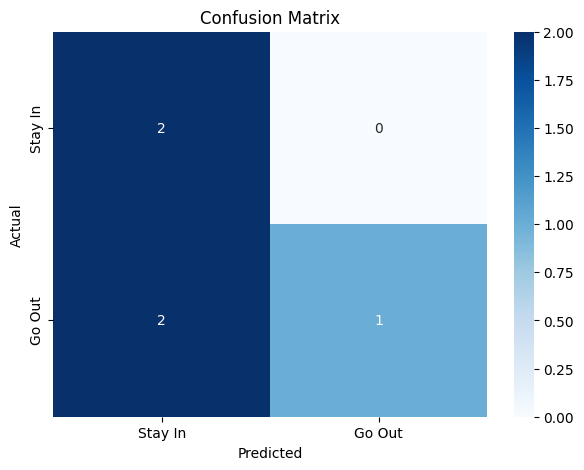

Confusion Matrix:
[[2 0]
 [2 1]]


In [20]:
# ============================================
# 20. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay In', 'Go Out'], yticklabels=['Stay In', 'Go Out'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Confusion Matrix:")
print(cm)

In [21]:
# ============================================
# 21. CLASSIFICATION REPORT
# ============================================

report = classification_report(y_test, y_pred, target_names=['Stay In', 'Go Out'])
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

     Stay In       0.50      1.00      0.67         2
      Go Out       1.00      0.33      0.50         3

    accuracy                           0.60         5
   macro avg       0.75      0.67      0.58         5
weighted avg       0.80      0.60      0.57         5



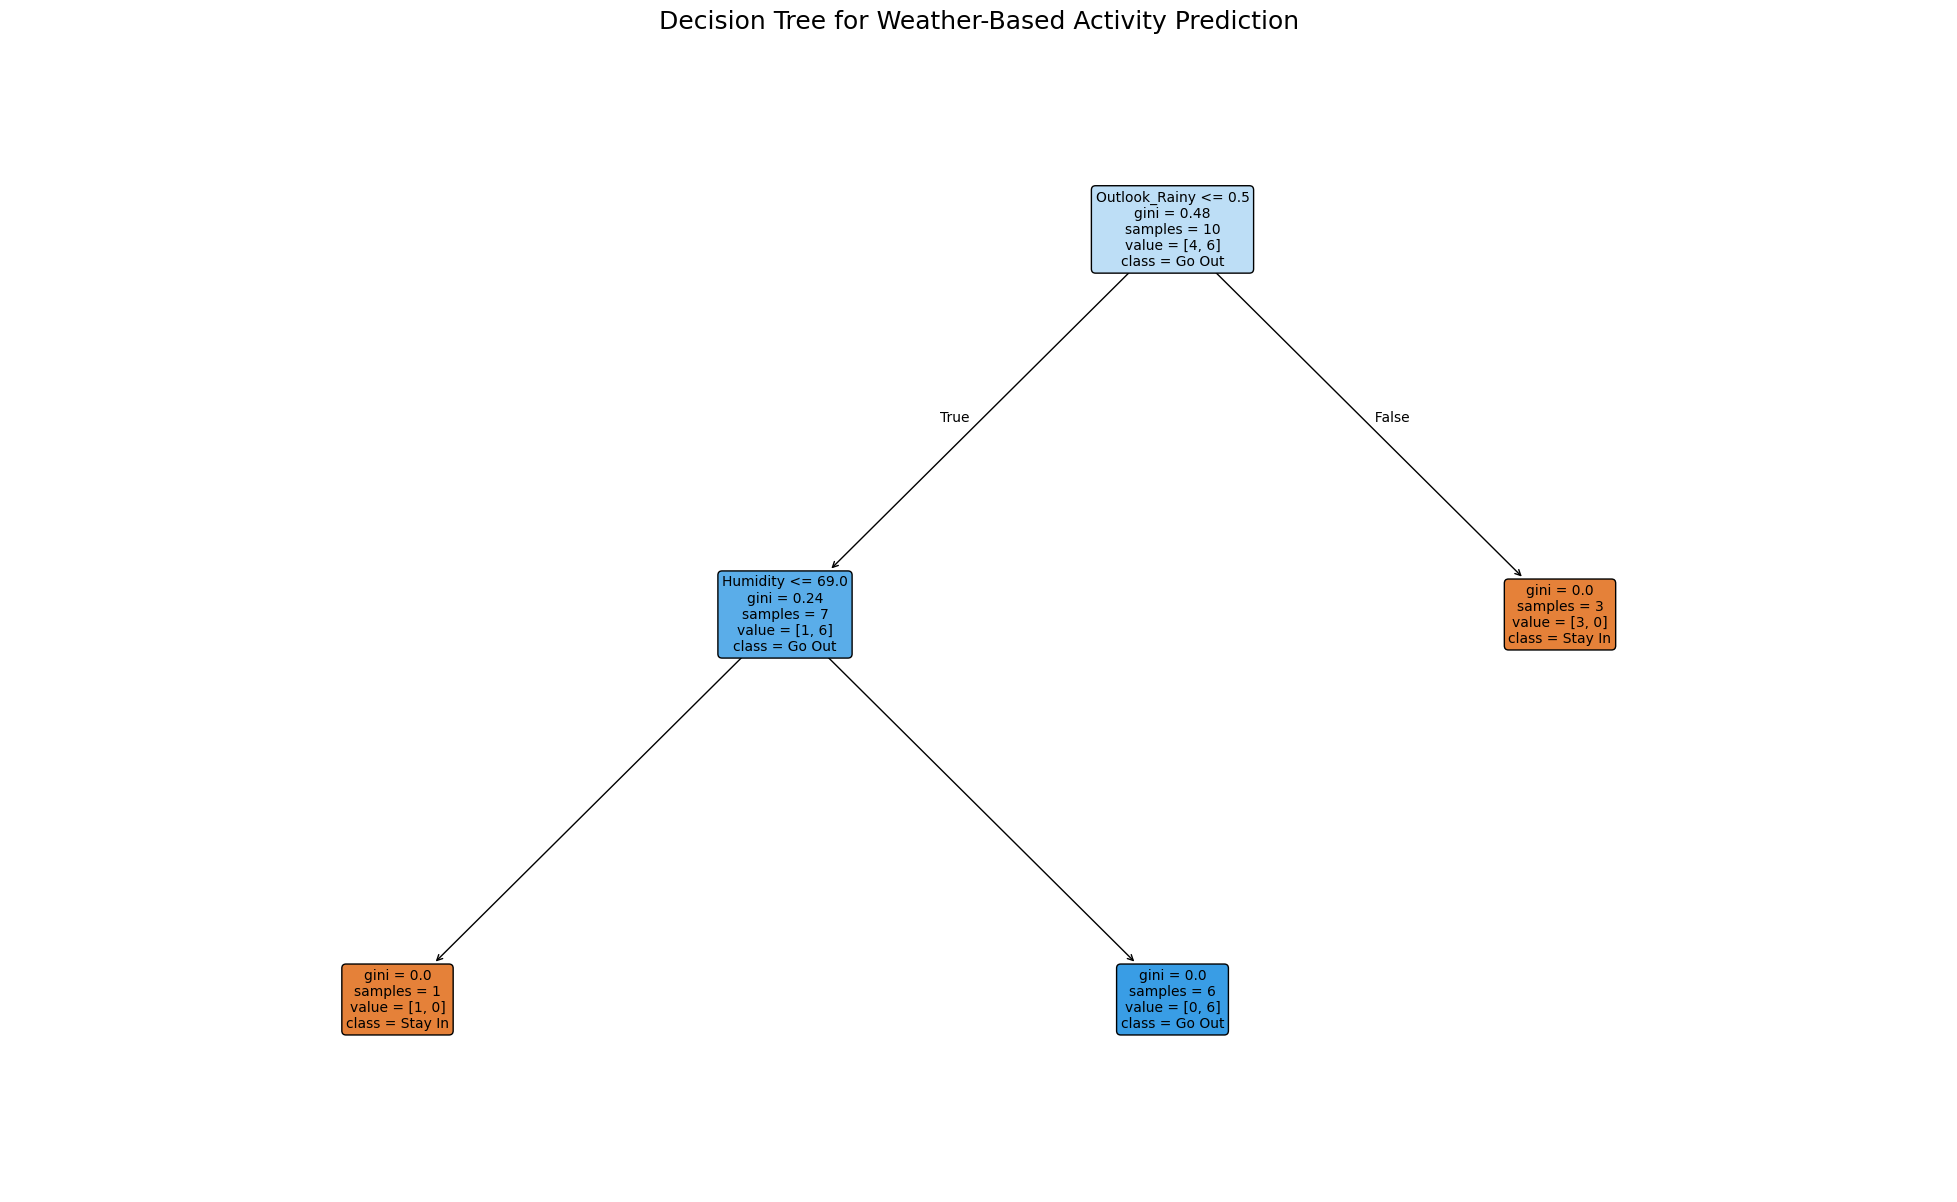

In [22]:
# ============================================
# 22. DECISION TREE VISUALIZATION
# ============================================

plt.figure(figsize=(25, 15)) # Make the figure large for readability
plot_tree(
    model,
    feature_names=X.columns.tolist(),
    class_names=['Stay In', 'Go Out'], # Class names for target mapping (0: Stay In, 1: Go Out)
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=False,
    precision=2,
    node_ids=False # Do not display node IDs
)
plt.title('Decision Tree for Weather-Based Activity Prediction', fontsize=18)
plt.show()

In [23]:
# ============================================
# 23. FEATURE IMPORTANCE
# ============================================

feature_importances = model.feature_importances_
feature_names = X.columns.tolist()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("Feature Importances:")
display(importance_df)

Feature Importances:


,Feature,Importance
3,Outlook_Rainy,0.642857
1,Humidity,0.357143
0,Temperature,0.000000
2,Outlook_Overcast,0.000000
4,Outlook_Sunny,0.000000
5,Windy_False,0.000000
6,Windy_True,0.000000


/tmp/ipykernel_2405/2714027059.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='rocket')


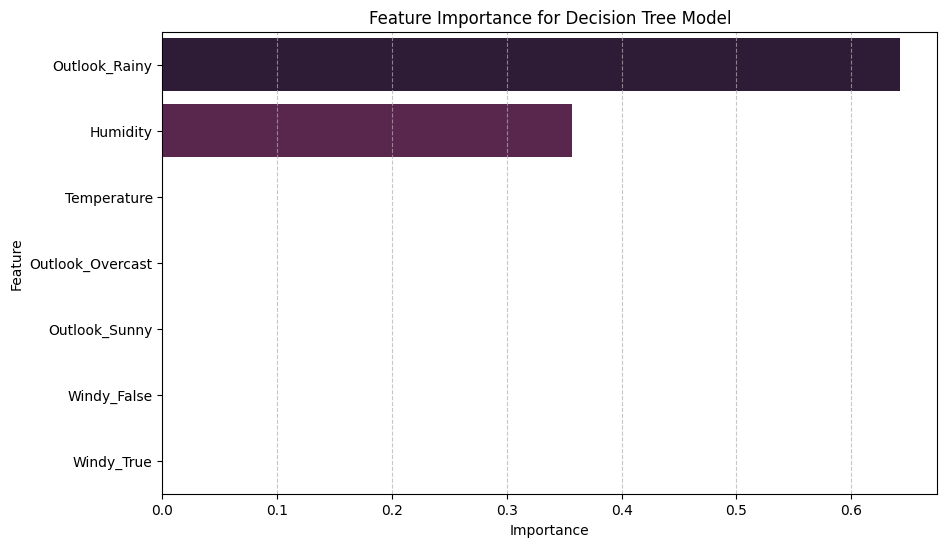

In [24]:
# ============================================
# 24. FEATURE IMPORTANCE GRAPH
# ============================================

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='rocket')
plt.title('Feature Importance for Decision Tree Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [25]:
# ============================================
# 25. PREDICT FOR A NEW WEATHER CONDITION
# ============================================

# Define a new weather condition for prediction
new_data = {
    'Outlook': ['Sunny'],
    'Temperature': [20],
    'Humidity': [70],
    'Windy': [False]
}
new_df = pd.DataFrame(new_data)

# Apply the same one-hot encoding as done for the training data
# Need to ensure all columns from X_train are present, even if 0

# Create a dummy dataframe with all possible categorical values to ensure consistent columns
# during encoding for new data.
# This is a robust way to handle new data if original categories are not present.
reference_df_for_dummies = pd.DataFrame(columns=['Outlook', 'Windy'])
reference_df_for_dummies = pd.concat([df[['Outlook', 'Windy']], reference_df_for_dummies], ignore_index=True)
reference_df_for_dummies = pd.get_dummies(reference_df_for_dummies, columns=['Outlook', 'Windy'], drop_first=False)

# Encode the new data
new_df_encoded = pd.get_dummies(new_df, columns=['Outlook', 'Windy'], drop_first=False)

# Align columns with the training data's features (X.columns)
missing_cols = set(X.columns) - set(new_df_encoded.columns)
for c in missing_cols:
    new_df_encoded[c] = 0

# Ensure the order of columns is the same as in X
new_df_encoded = new_df_encoded[X.columns]

print("Encoded new weather condition:")
display(new_df_encoded)

# Make prediction
prediction_numeric = model.predict(new_df_encoded)
prediction_proba = model.predict_proba(new_df_encoded)

# Map numerical prediction back to original class label
predicted_decision = 'Go Out' if prediction_numeric[0] == 1 else 'Stay In'

print(f"\nPredicted Decision for the new weather condition: {predicted_decision}")
print(f"Probability of 'Stay In': {prediction_proba[0][0]:.2f}")
print(f"Probability of 'Go Out': {prediction_proba[0][1]:.2f}")

Encoded new weather condition:


,Temperature,Humidity,Outlook_Overcast,Outlook_Rainy,Outlook_Sunny,Windy_False,Windy_True
0,20,70,0,0,True,True,0



Predicted Decision for the new weather condition: Go Out
Probability of 'Stay In': 0.00
Probability of 'Go Out': 1.00


In [26]:
# ============================================
# 26. FINAL MODEL RESULTS
# ============================================

final_accuracy = accuracy_score(y_test, y_pred) * 100

print("Model: Decision Tree Classifier")
print(f"Accuracy: {final_accuracy:.2f}%")
print(f"Criterion: {model.criterion.capitalize()} Impurity")

Model: Decision Tree Classifier
Accuracy: 60.00%
Criterion: Gini Impurity


## Observation

From the trained Decision Tree model and its visualization:

Decision trees split the weather data into subsets by the most important features at each node. For instance, the most important feature might be 'Outlook' or 'Humidity' at top nodes due to its large impact on the decision process.
'Outlook_Rainy', 'Humidity', and 'Temperature' seem to be important features in influencing the decision 'Go Out' or 'Stay In'. For example, high values of humidity or 'rainy' outlook usually result in decision 'Stay In'.
The metric Gini impurity is used for the measurement of node impurity. Low Gini impurity corresponds to purer node, when most samples in the node have the same class label. The tree tries to produce such splits that lead to pure nodes.
From the feature importance chart, we can conclude that Outlook_Rainy and Humidity are among the features with high importance.

## Conclusion

A decision tree classifier was built in this lab experiment to determine whether a person should choose to 'Go Out' or 'Stay In' depending on certain weather parameters. 'Outlook', 'Temperature', 'Humidity' and 'Windy' were used as an example dataset.

The classifier was built and then evaluated with the use of such metrics as accuracy, confusion matrix and classification report. The decision tree visualization allowed getting a better idea about how the classifier made its predictions by using various weather parameters and corresponding thresholds. Analysis of feature importance showed which weather parameters played the most significant role in the prediction process.